In [1]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

In [2]:
df=pd.read_csv(r"C:\Users\NARENDRA\Downloads\Random Forests - Assignment -5\10. Random Forests\Company_Data.csv")
df.head()

,Sales,CompPrice,Income,Advertising,Population,Price,ShelveLoc,Age,Education,Urban,US
0,9.50,138,73,11,276,120,Bad,42,17,Yes,Yes
1,11.22,111,48,16,260,83,Good,65,10,Yes,Yes
2,10.06,113,35,10,269,80,Medium,59,12,Yes,Yes
3,7.40,117,100,4,466,97,Medium,55,14,Yes,Yes
4,4.15,141,64,3,340,128,Bad,38,13,Yes,No


In [3]:
df.shape

(400, 11)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Sales        400 non-null    float64
 1   CompPrice    400 non-null    int64  
 2   Income       400 non-null    int64  
 3   Advertising  400 non-null    int64  
 4   Population   400 non-null    int64  
 5   Price        400 non-null    int64  
 6   ShelveLoc    400 non-null    object 
 7   Age          400 non-null    int64  
 8   Education    400 non-null    int64  
 9   Urban        400 non-null    object 
 10  US           400 non-null    object 
dtypes: float64(1), int64(7), object(3)
memory usage: 34.5+ KB


In [5]:
df.isnull().sum()

Sales          0
CompPrice      0
Income         0
Advertising    0
Population     0
Price          0
ShelveLoc      0
Age            0
Education      0
Urban          0
US             0
dtype: int64

In [6]:
df.describe()

,Sales,CompPrice,Income,Advertising,Population,Price,Age,Education
count,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000
mean,7.496325,124.975000,68.657500,6.635000,264.840000,115.795000,53.322500,13.900000
std,2.824115,15.334512,27.986037,6.650364,147.376436,23.676664,16.200297,2.620528
min,0.000000,77.000000,21.000000,0.000000,10.000000,24.000000,25.000000,10.000000
25%,5.390000,115.000000,42.750000,0.000000,139.000000,100.000000,39.750000,12.000000
50%,7.490000,125.000000,69.000000,5.000000,272.000000,117.000000,54.500000,14.000000
75%,9.320000,135.000000,91.000000,12.000000,398.500000,131.000000,66.000000,16.000000
max,16.270000,175.000000,120.000000,29.000000,509.000000,191.000000,80.000000,18.000000


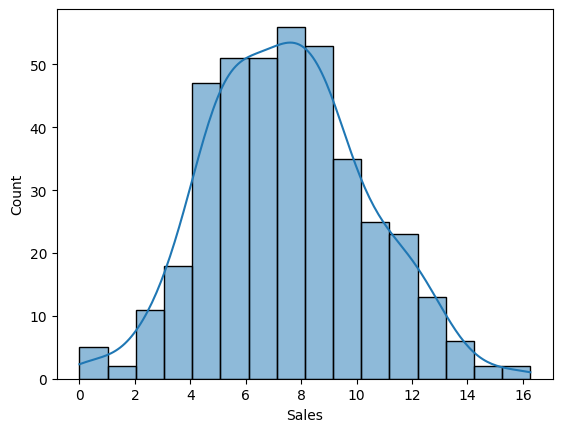

In [7]:
sns.histplot(df["Sales"], kde=True)

plt.show()

In [8]:
df["Sales_Category"] = np.where(
    df["Sales"] > df["Sales"].median(),
    "High",
    "Low"
)

df["Sales_Category"].value_counts()

Sales_Category
Low     201
High    199
Name: count, dtype: int64

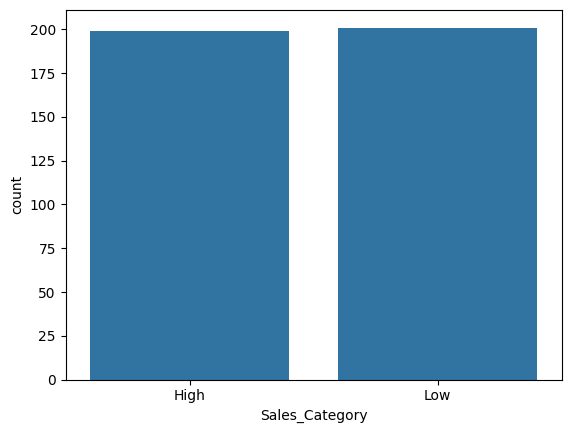

In [9]:
sns.countplot(
    data=df,
    x="Sales_Category"
)

plt.show()

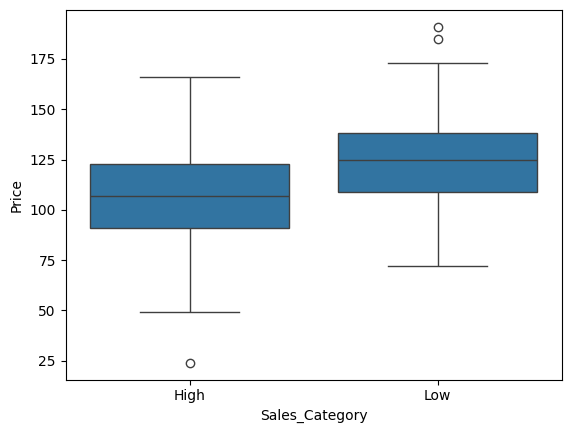

In [10]:
sns.boxplot(
    data=df,
    x="Sales_Category",
    y="Price"
)

plt.show()

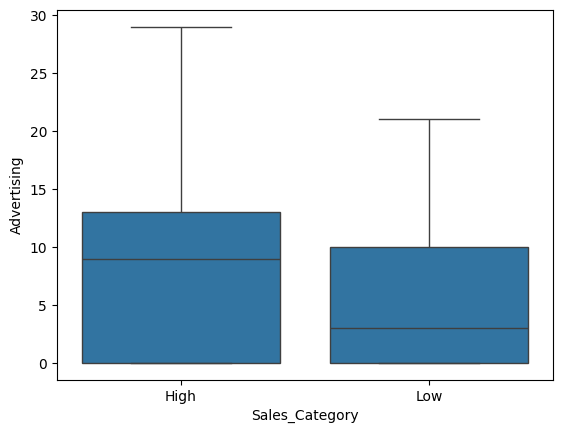

In [11]:
sns.boxplot(
    data=df,
    x="Sales_Category",
    y="Advertising"
)

plt.show()

In [12]:
encoder = LabelEncoder()

df["ShelveLoc"] = encoder.fit_transform(df["ShelveLoc"])
df["Urban"] = encoder.fit_transform(df["Urban"])
df["US"] = encoder.fit_transform(df["US"])
df["Sales_Category"] = encoder.fit_transform(df["Sales_Category"])

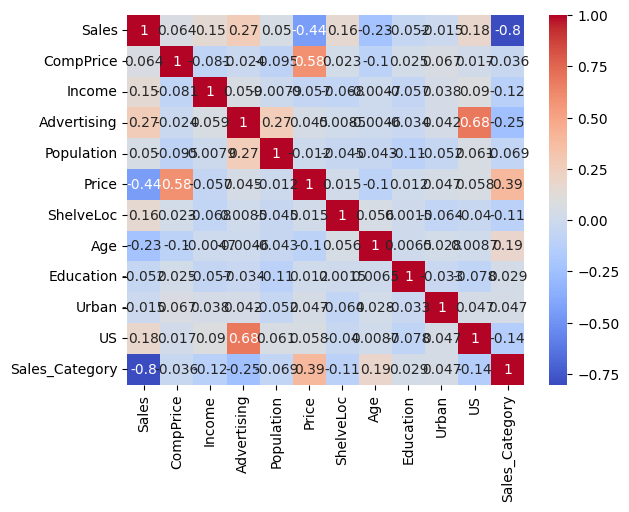

In [13]:
corr = df.corr(numeric_only=True)

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.show()

In [14]:
X = df.drop(
    ["Sales", "Sales_Category"],
    axis=1
)

y = df["Sales_Category"]

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [16]:
model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

model.fit(
    X_train,
    y_train
)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [17]:
y_pred = model.predict(X_test)

In [18]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

print(accuracy)

0.7875


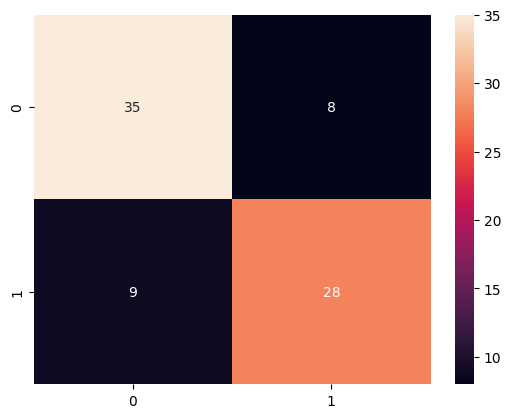

In [19]:
cm = confusion_matrix(
    y_test,
    y_pred
)

sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)

plt.show()

In [20]:
print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.80      0.81      0.80        43
           1       0.78      0.76      0.77        37

    accuracy                           0.79        80
   macro avg       0.79      0.79      0.79        80
weighted avg       0.79      0.79      0.79        80



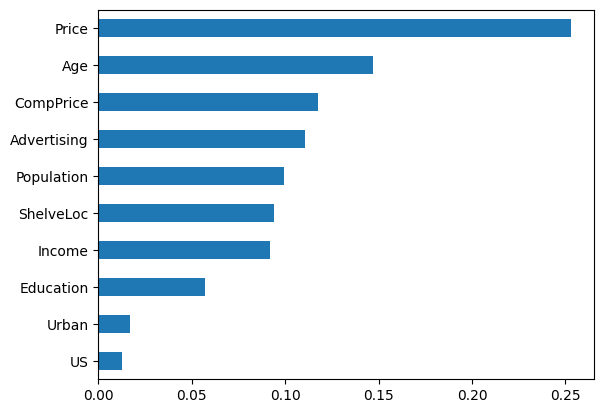

In [21]:
importance = pd.Series(
    model.feature_importances_,
    index=X.columns
)

importance.sort_values().plot(
    kind="barh"
)

plt.show()

In [22]:
# Fraud check

In [24]:
df=pd.read_csv(r"C:\Users\NARENDRA\Downloads\Random Forests - Assignment -5\10. Random Forests\Fraud_check.csv")
df.head()

,Undergrad,Marital.Status,Taxable.Income,City.Population,Work.Experience,Urban
0,NO,Single,68833,50047,10,YES
1,YES,Divorced,33700,134075,18,YES
2,NO,Married,36925,160205,30,YES
3,YES,Single,50190,193264,15,YES
4,NO,Married,81002,27533,28,NO


In [25]:
df["Risk"] = np.where(
    df["Taxable.Income"] <= 30000,
    "Risky",
    "Good"
)

df["Risk"].value_counts()

Risk
Good     476
Risky    124
Name: count, dtype: int64

In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Undergrad        600 non-null    object
 1   Marital.Status   600 non-null    object
 2   Taxable.Income   600 non-null    int64 
 3   City.Population  600 non-null    int64 
 4   Work.Experience  600 non-null    int64 
 5   Urban            600 non-null    object
 6   Risk             600 non-null    object
dtypes: int64(3), object(4)
memory usage: 32.9+ KB


In [28]:
df.describe()

,Taxable.Income,City.Population,Work.Experience
count,600.000000,600.000000,600.000000
mean,55208.375000,108747.368333,15.558333
std,26204.827597,49850.075134,8.842147
min,10003.000000,25779.000000,0.000000
25%,32871.500000,66966.750000,8.000000
50%,55074.500000,106493.500000,15.000000
75%,78611.750000,150114.250000,24.000000
max,99619.000000,199778.000000,30.000000


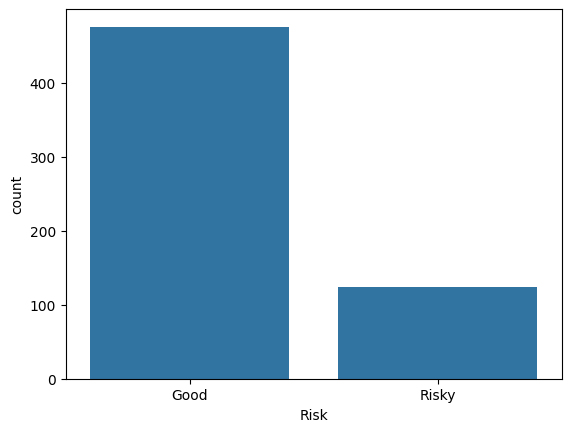

In [29]:
sns.countplot(
    data=df,
    x="Risk"
)

plt.show()

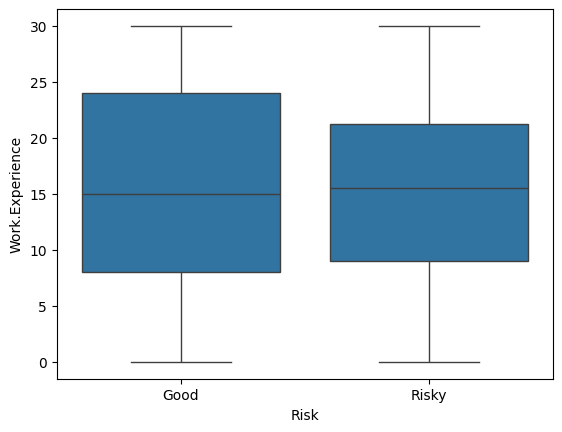

In [30]:
sns.boxplot(
    data=df,
    x="Risk",
    y="Work.Experience"
)

plt.show()

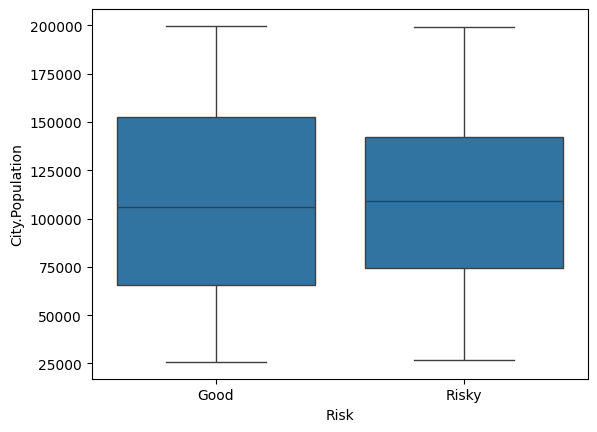

In [31]:
sns.boxplot(
    data=df,
    x="Risk",
    y="City.Population"
)

plt.show()

In [32]:
encoder = LabelEncoder()

df["Undergrad"] = encoder.fit_transform(df["Undergrad"])
df["Marital.Status"] = encoder.fit_transform(df["Marital.Status"])
df["Urban"] = encoder.fit_transform(df["Urban"])
df["Risk"] = encoder.fit_transform(df["Risk"])

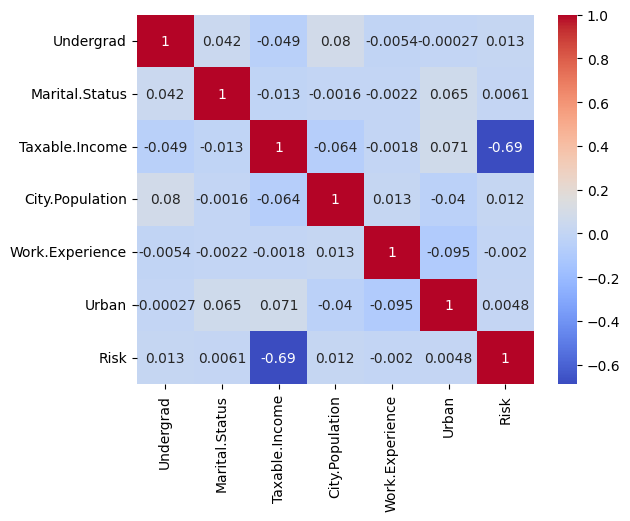

In [33]:
corr = df.corr(numeric_only=True)

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.show()

In [34]:
X = df.drop(
    ["Taxable.Income", "Risk"],
    axis=1
)

y = df["Risk"]

In [35]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [36]:
model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

model.fit(
    X_train,
    y_train
)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [37]:
y_pred = model.predict(X_test)

In [38]:
print(
    accuracy_score(
        y_test,
        y_pred
    )
)

0.7583333333333333


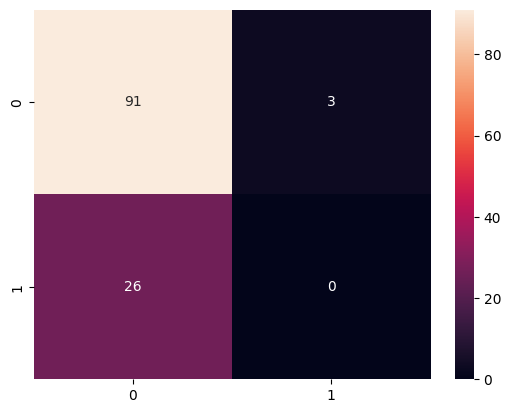

In [39]:
cm = confusion_matrix(
    y_test,
    y_pred
)

sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)

plt.show()

In [40]:
print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.78      0.97      0.86        94
           1       0.00      0.00      0.00        26

    accuracy                           0.76       120
   macro avg       0.39      0.48      0.43       120
weighted avg       0.61      0.76      0.68       120



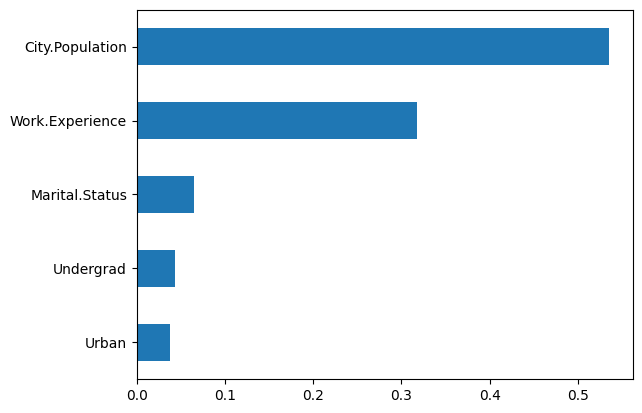

In [41]:
importance = pd.Series(
    model.feature_importances_,
    index=X.columns
)

importance.sort_values().plot(
    kind="barh"
)

plt.show()